Figure S17: Height colocalization for a HOXB cluster pcQTL. A Credible set group graph for the cluster. B QTL nominal p-values for each gene’s expression and each PC vs genomic position. If the phenotype has any significant credible sets, a plot is shown for each credible set, with credible set variants highlighted and colors given by variant LD with the credible-set lead variant. C GWAS variant nominal p-values vs QTL nominal p-values for each gene’s expression and each PC. If the phenotype has any significant credible sets, a plot is shown for each credible set with the credible set variants highlighted and the highest PPH4 (probability of colocalization) is given between QTL credible set and any GWAS credible sets.

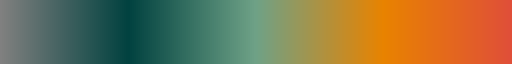

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 
from matplotlib.colors import LinearSegmentedColormap
import matplotlib as mpl

from tqdm.auto import tqdm 
tqdm.pandas()

prefix = '/home/klawren/oak/pcqtls'
import yaml
config_path= f'{prefix}/config_old/main_pcqtl.yaml'
with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

import sys
sys.path.append(f'{config["working_dir"]}/{config["code_dir"]}')
from utils import *

%config InlineBackend.figure_formats = ['png']

plt.rcParams.update({
    'font.size': 8,           # Base font size
    'axes.labelsize': 9,      # Axis labels
    'axes.titlesize': 10,     # Subplot titles
    'xtick.labelsize': 8,     # X-axis tick labels
    'ytick.labelsize': 8,     # Y-axis tick labels
    'legend.fontsize': 8,     # Legend
    'pdf.fonttype': 42,       # Embed fonts in PDF
    'ps.fonttype': 42,        # Embed fonts in PS
})

qtl_palette = {'pcQTL only':'#62005A', 'eQTL only':'#6FA287', 'Both':'#007C92', 'Neither':'grey'}

ld_palette = LinearSegmentedColormap.from_list(
    "darkblue_green_yellow_red",
    ["grey", "#014240", "#6FA287", "#E98300", "#E04F39"]
)
ld_norm = mpl.colors.Normalize(vmin=0, vmax=1)
ld_palette

In [ ]:
example_signal_id = 'ENSG00000108511.9_ENSG00000120068.6_ENSG00000120075.5_ENSG00000120093.11_ENSG00000182742.5_ENSG00000260027.4_pc4_cs_2-gwas_GIANT_HEIGHT_cluster_ENSG00000108511.9_ENSG00000120068.6_ENSG00000120075.5_ENSG00000120093.11_ENSG00000182742.5_ENSG00000260027.4_cs_5'
example_cluster_id = 'ENSG00000108511.9_ENSG00000120068.6_ENSG00000120075.5_ENSG00000120093.11_ENSG00000182742.5_ENSG00000260027.4'
example_tissue_id = 'Esophagus_Muscularis'
example_cs_id = 'ENSG00000108511.9_ENSG00000120068.6_ENSG00000120075.5_ENSG00000120093.11_ENSG00000182742.5_ENSG00000260027.4_pc4_cs_2'
example_gwas_id = 'GIANT_HEIGHT_cs_5_cluster_ENSG00000108511.9_ENSG00000120068.6_ENSG00000120075.5_ENSG00000120093.11_ENSG00000182742.5_ENSG00000260027.4'
example_lead_variant_id = 'chr17_48584210_C_T_b38'
example_gwas_traits = ["GIANT_HEIGHT"]
gwas_names = ['Height']

In [3]:
susie_annotated = load_susie_annotated(config, example_tissue_id)
gwas_signals = load_across_tissues(config, load_gwas_signal_groups)

In [56]:
example_coloc = gwas_signals[gwas_signals['signal_id'] == example_signal_id].iloc[0]
example_cs = susie_annotated[susie_annotated['cs_id'] == example_cs_id]
example_var = example_cs.iloc[0]
example_lead_variant_id = example_cs[example_cs['pip'] == example_cs['pip'].max()]['variant_id'].iloc[0]

In [5]:
# bring in the nominal p values
nominal_e = load_e_nominal(config, example_var['tissue_id'], example_var['chr'])
nominal_pc = load_pc_nominal(config, example_var['tissue_id'], example_var['chr'])

In [6]:
# bring in gwas summary stats
gwas_data = []
for example_gwas_trait in example_gwas_traits:
    gwas_path = f'/oak/stanford/groups/smontgom/shared/gwas_summary_stats/barbeira_gtex_imputed/imputed_gwas_hg38_1.1/imputed_{example_gwas_trait}.txt.gz'
    example_gwas = pd.read_csv(gwas_path, sep='\t')
    gwas_data.append(example_gwas)

In [7]:
# subset the nomal p values
nominal_e = nominal_e[(nominal_e['cluster_id'] == example_coloc['cluster_id'])]
nominal_pc = nominal_pc[(nominal_pc['cluster_id'] == example_coloc['cluster_id'])]
for i in range(len(gwas_data)):
    gwas_data[i] = gwas_data[i][gwas_data[i]['panel_variant_id'].isin(nominal_e['variant_id'])]

In [8]:
# load in ld
ld_path = f'{config["working_dir"]}/{config["coloc_output_dir"]}/temp/ld/{example_cluster_id}.ld'
ld = pd.read_table(ld_path, sep='\t', header=None)
snp_list_path = f'{config["working_dir"]}/{config["coloc_output_dir"]}/temp/ld/{example_cluster_id}.snp_list.txt'
snps = pd.read_table(snp_list_path, header=None)
ld.columns = snps[0].values
ld.index = snps[0].values

In [9]:
# load in individual gwas coloc results 
gwas_coloc = []
for gwas_trait in example_gwas_traits:
    gwas_path = f'{config["working_dir"]}/{config["coloc_output_dir"]}gwas_susie_True/{example_tissue_id}/{example_tissue_id}.v8.{gwas_trait}.gwas_coloc.txt'
    gwas_coloc.append(pd.read_csv(gwas_path, sep='\t'))

gwas_coloc = pd.concat(gwas_coloc)
cluster_gwas_coloc = gwas_coloc[gwas_coloc['qtl_id'].str.contains(example_cluster_id)]
# Display the cluster_gwas_coloc DataFrame with a wider 'qtl_id' column for better readability
with pd.option_context('display.max_colwidth', 120):
    display(cluster_gwas_coloc)

,gwas_id,qtl_id,nsnps,hit1,hit2,PP.H0.abf,PP.H1.abf,PP.H2.abf,PP.H3.abf,PP.H4.abf,idx1,idx2,gwas_cs_is,qtl_cs_is
2415,GIANT_HEIGHT,ENSG00000108511.9_ENSG00000120068.6_ENSG00000120075.5_ENSG00000120093.11_ENSG00000182742.5_ENSG00000260027.4_e_ENSG0...,1160,chr17_48584210_C_T_b38,chr17_48583930_G_A_b38,2.474220e-51,0.000431,5.743579e-48,0.999522,0.000047,5,1,5,1
2416,GIANT_HEIGHT,ENSG00000108511.9_ENSG00000120068.6_ENSG00000120075.5_ENSG00000120093.11_ENSG00000182742.5_ENSG00000260027.4_e_ENSG0...,1160,chr17_48533217_C_A_b38,chr17_48583930_G_A_b38,5.888088e-25,0.000431,1.366843e-21,0.999534,0.000035,7,1,7,1
2417,GIANT_HEIGHT,ENSG00000108511.9_ENSG00000120068.6_ENSG00000120075.5_ENSG00000120093.11_ENSG00000182742.5_ENSG00000260027.4_e_ENSG0...,1160,chr17_49156755_T_G_b38,chr17_48583930_G_A_b38,7.105511e-07,0.000430,1.649452e-03,0.997888,0.000032,8,1,8,1
2418,GIANT_HEIGHT,ENSG00000108511.9_ENSG00000120068.6_ENSG00000120075.5_ENSG00000120093.11_ENSG00000182742.5_ENSG00000260027.4_e_ENSG0...,1160,chr17_48602805_G_A_b38,chr17_48583930_G_A_b38,2.501106e-11,0.000431,5.805991e-08,0.999563,0.000007,9,1,9,1
2419,GIANT_HEIGHT,ENSG00000108511.9_ENSG00000120068.6_ENSG00000120075.5_ENSG00000120093.11_ENSG00000182742.5_ENSG00000260027.4_e_ENSG0...,1160,chr17_49352472_A_G_b38,chr17_48583930_G_A_b38,1.352685e-11,0.000431,3.140082e-08,0.999479,0.000090,2,1,2,1
2420,GIANT_HEIGHT,ENSG00000108511.9_ENSG00000120068.6_ENSG00000120075.5_ENSG00000120093.11_ENSG00000182742.5_ENSG00000260027.4_e_ENSG0...,1160,chr17_48897372_T_C_b38,chr17_48583930_G_A_b38,1.790866e-15,0.000431,4.157261e-12,0.999560,0.000009,1,1,1,1
2421,GIANT_HEIGHT,ENSG00000108511.9_ENSG00000120068.6_ENSG00000120075.5_ENSG00000120093.11_ENSG00000182742.5_ENSG00000260027.4_e_ENSG0...,1160,chr17_47944699_G_A_b38,chr17_48583930_G_A_b38,1.121551e-05,0.000419,2.603535e-02,0.973241,0.000293,4,1,4,1
2422,GIANT_HEIGHT,ENSG00000108511.9_ENSG00000120068.6_ENSG00000120075.5_ENSG00000120093.11_ENSG00000182742.5_ENSG00000260027.4_e_ENSG0...,1160,chr17_48018910_C_T_b38,chr17_48583930_G_A_b38,2.783279e-06,0.000428,6.461018e-03,0.992918,0.000190,3,1,3,1
2423,GIANT_HEIGHT,ENSG00000108511.9_ENSG00000120068.6_ENSG00000120075.5_ENSG00000120093.11_ENSG00000182742.5_ENSG00000260027.4_e_ENSG0...,1160,chr17_47698964_T_G_b38,chr17_48583930_G_A_b38,9.639808e-07,0.000430,2.237755e-03,0.997252,0.000080,6,1,6,1
2424,GIANT_HEIGHT,ENSG00000108511.9_ENSG00000120068.6_ENSG00000120075.5_ENSG00000120093.11_ENSG00000182742.5_ENSG00000260027.4_pc4,1160,chr17_48584210_C_T_b38,chr17_48584210_C_T_b38,2.217776e-52,0.000039,1.154191e-50,0.000009,0.999953,5,2,5,2


In [10]:
# load in individual abf gwas coloc results 
abf_gwas_coloc = []
for gwas_trait in example_gwas_traits:
    gwas_path = f'{config["working_dir"]}/{config["coloc_output_dir"]}gwas_susie_False/{example_tissue_id}/{example_tissue_id}.v8.{gwas_trait}.gwas_coloc.txt'
    abf_gwas_coloc.append(pd.read_csv(gwas_path, sep='\t'))

abf_gwas_coloc = pd.concat(abf_gwas_coloc)
cluster_abf_gwas_coloc = abf_gwas_coloc[abf_gwas_coloc['qtl_id'].str.contains(example_cluster_id)]
cluster_abf_gwas_coloc

,gwas_id,qtl_id,PP.H0.abf,PP.H1.abf,PP.H2.abf,PP.H3.abf,PP.H4.abf
878,GIANT_HEIGHT,ENSG00000108511.9_ENSG00000120068.6_ENSG000001...,1.279926e-13,0.000471,2.714355e-10,0.999525,0.000003
879,GIANT_HEIGHT,ENSG00000108511.9_ENSG00000120068.6_ENSG000001...,7.426004e-13,0.002735,2.708193e-10,0.997257,0.000009


In [11]:
def plot_egene_coloc(ax, gene_name, example_egene_id, nominal_e, example_gwas, gwas_name, plot_egene_cs=True, plot_example_cs=True):
    egene_pvalues = nominal_e[(nominal_e['egene_id']==example_egene_id)][['variant_id', 'pval_nominal']]
    gwas_egene_pvalues_merged = pd.merge(egene_pvalues, example_gwas[['panel_variant_id', 'pvalue']], left_on='variant_id', right_on='panel_variant_id', how='inner')
    gwas_egene_pvalues_merged['qtl_pvalue'] = -np.log10(gwas_egene_pvalues_merged['pval_nominal'].astype(float))
    gwas_egene_pvalues_merged['gwas_pvalue'] = -np.log10(gwas_egene_pvalues_merged['pvalue'].astype(float))

    sns.scatterplot(gwas_egene_pvalues_merged, x='qtl_pvalue', y='gwas_pvalue', s=2, alpha=1, edgecolor=None, ax=ax, color='grey', legend=False)

    if plot_example_cs:
        example_cs_lead_variant_id = example_cs[example_cs['pip'] == example_cs['pip'].max()]['variant_id'].iloc[0]
        sns.scatterplot(gwas_egene_pvalues_merged[gwas_egene_pvalues_merged['variant_id'].isin(example_cs['variant_id'])], x='qtl_pvalue', y='gwas_pvalue', s=40*example_cs['pip'], alpha=1, linewidth=1.5, edgecolor='#62005A', ax=ax, color='lightgrey', legend=False)
        sns.scatterplot(gwas_egene_pvalues_merged[gwas_egene_pvalues_merged['variant_id'].isin([example_cs_lead_variant_id])], x='qtl_pvalue', y='gwas_pvalue', s=40, alpha=1, linewidth=1.5, edgecolor='#62005A', ax=ax, color='lightgrey', marker='D', legend=False)

    if plot_egene_cs:
        egene_cs = susie_annotated[susie_annotated['phenotype_id'] == example_cluster_id + '_e_' + example_egene_id]
        if len(egene_cs) > 0:
            egene_cs_lead_variant_id = egene_cs.groupby('cs_id').apply(lambda x: x[x['pip'] == x['pip'].max()]['variant_id'].iloc[0]).reset_index(name='variant_id')['variant_id'].values
            sns.scatterplot(gwas_egene_pvalues_merged[gwas_egene_pvalues_merged['variant_id'].isin(egene_cs['variant_id'])], x='qtl_pvalue', y='gwas_pvalue', s=20, alpha=1, linewidth=1, ax=ax, edgecolor='k', color='#417865', legend=False)
            sns.scatterplot(gwas_egene_pvalues_merged[gwas_egene_pvalues_merged['variant_id'].isin(egene_cs_lead_variant_id)], x='qtl_pvalue', y='gwas_pvalue', s=40, alpha=1, linewidth=1, edgecolor='k', ax=ax, color='#417865', marker='D', legend=False)
 

    ax.spines[['right', 'top']].set_visible(False)
    ax.set_xlabel(f'{gene_name} -log10(p-value)')
    ax.set_ylabel(f'{gwas_name} -log10(p-value)')
    return ax

In [12]:
def plot_pcgene_coloc(ax, example_pc_num, nominal_pc, example_gwas, gwas_name, plot_example_cs=True, plot_pc_cs=True):
    pc_pvalues = nominal_pc[(nominal_pc['pc_num']==example_pc_num)][['variant_id', 'pval_nominal']]
    gwas_pc_pvalues_merged = pd.merge(pc_pvalues, example_gwas[['panel_variant_id', 'pvalue']], left_on='variant_id', right_on='panel_variant_id', how='inner')
    gwas_pc_pvalues_merged['qtl_pvalue'] = -np.log10(gwas_pc_pvalues_merged['pval_nominal'].astype(float))
    gwas_pc_pvalues_merged['gwas_pvalue'] = -np.log10(gwas_pc_pvalues_merged['pvalue'].astype(float))

    sns.scatterplot(gwas_pc_pvalues_merged, x='qtl_pvalue', y='gwas_pvalue', s=2, alpha=1, edgecolor=None, ax=ax, color='grey', legend=False)

    if plot_example_cs:
        sns.scatterplot(gwas_pc_pvalues_merged[gwas_pc_pvalues_merged['variant_id'].isin(example_cs['variant_id'])], x='qtl_pvalue', y='gwas_pvalue', s=20, alpha=1, linewidth=1.5, edgecolor='#62005A', ax=ax, color='lightgrey', legend=False)
        example_cs_lead_variant_id = example_cs[example_cs['pip'] == example_cs['pip'].max()]['variant_id'].iloc[0]
        sns.scatterplot(gwas_pc_pvalues_merged[gwas_pc_pvalues_merged['variant_id'].isin([example_cs_lead_variant_id])], x='qtl_pvalue', y='gwas_pvalue', s=40, alpha=1, linewidth=1.5, edgecolor='#62005A', ax=ax, color='lightgrey',  marker='D', legend=False)

    if plot_pc_cs:
        pc_cs = susie_annotated[susie_annotated['phenotype_id'] == example_cluster_id + '_pc' + str(example_pc_num)]
        if len(pc_cs) > 0:
            pc_cs_lead_variant_id = pc_cs.groupby('cs_id').apply(lambda x: x[x['pip'] == x['pip'].max()]['variant_id'].iloc[0]).reset_index(name='variant_id')['variant_id'].values
            sns.scatterplot(gwas_pc_pvalues_merged[gwas_pc_pvalues_merged['variant_id'].isin(pc_cs['variant_id'])], x='qtl_pvalue', y='gwas_pvalue', s=20, alpha=1, linewidth=1.5, edgecolor='k', ax=ax, color='#62005A', legend=False)
            pc_cs_lead_variant_id = pc_cs[pc_cs['pip'] == pc_cs['pip'].max()]['variant_id'].iloc[0]
            sns.scatterplot(gwas_pc_pvalues_merged[gwas_pc_pvalues_merged['variant_id'].isin([pc_cs_lead_variant_id])], x='qtl_pvalue', y='gwas_pvalue', s=40, alpha=1, linewidth=1.5, ax=ax, edgecolor='k', color='#62005A', marker='D', legend=False)

    ax.spines[['right', 'top']].set_visible(False)
    ax.set_xlabel(f'PC{example_pc_num} -log10(p-value)')
    ax.set_ylabel(f'{gwas_name} -log10(p-value)')
    return ax

In [13]:
# cluster coloc graph
coloc_cutoff = 0.75
pair_coloc_qtl = load_pairwise_coloc(config, example_tissue_id)

# get the gwas-qtl coloc pairs
cluster_gwas_pairs = gwas_coloc[(gwas_coloc['qtl_id'].str.contains(example_cluster_id))]
cluster_gwas_pairs['id1_short'] = np.where(cluster_gwas_pairs['qtl_id'].str.contains('_e_'), cluster_gwas_pairs['qtl_id'].str.split('_e_').str[-1], 'PC' + cluster_gwas_pairs['qtl_id'].str.split('_pc').str[-1])
cluster_gwas_pairs['id2_short'] = 'gwas-' + cluster_gwas_pairs['gwas_id'] + '\ncs' + cluster_gwas_pairs['idx1'].astype(str)
cluster_gwas_pairs['id1_short'] = cluster_gwas_pairs['id1_short'].apply(get_gene_name, config=config) + '\ncs' + cluster_gwas_pairs['qtl_cs_is'].astype(int).astype(str)
# drop out GWAS that don't coloc with anything
gwas_max_pph4 = cluster_gwas_pairs.groupby('idx1').agg({'PP.H4.abf':'max'})
cluster_gwas_pairs = cluster_gwas_pairs[cluster_gwas_pairs['idx1'].isin(gwas_max_pph4[gwas_max_pph4['PP.H4.abf'] > coloc_cutoff].index.values)]

# load in the pair qlt-qtl colocs too
pair_coloc_qtl['cluster_id'] = pair_coloc_qtl['qtl1_id'].str.split('_e_').str[0].str.split('_pc').str[0]
cluster_pairs_qtl = pair_coloc_qtl[pair_coloc_qtl['cluster_id'] == example_cluster_id]
cluster_pairs_qtl['id1_short'] = np.where(cluster_pairs_qtl['qtl1_id'].str.contains('_e_'), cluster_pairs_qtl['qtl1_id'].str.split('_e_').str[-1], 'PC' + cluster_pairs_qtl['qtl1_id'].str.split('_pc').str[-1])
cluster_pairs_qtl['id2_short'] = np.where(cluster_pairs_qtl['qtl2_id'].str.contains('_e_'), cluster_pairs_qtl['qtl2_id'].str.split('_e_').str[-1], 'PC' + cluster_pairs_qtl['qtl2_id'].str.split('_pc').str[-1])
cluster_pairs_qtl['id1_short'] = cluster_pairs_qtl['id1_short'].apply(get_gene_name, config=config) + '\ncs' + cluster_pairs_qtl['idx1'].astype(str)
cluster_pairs_qtl['id2_short'] = cluster_pairs_qtl['id2_short'].apply(get_gene_name, config=config)+ '\ncs' + cluster_pairs_qtl['idx2'].astype(str)


/local/scratch/klawren/slrmtmp.48797752/ipykernel_40930/2906043469.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster_gwas_pairs['id1_short'] = np.where(cluster_gwas_pairs['qtl_id'].str.contains('_e_'), cluster_gwas_pairs['qtl_id'].str.split('_e_').str[-1], 'PC' + cluster_gwas_pairs['qtl_id'].str.split('_pc').str[-1])
/local/scratch/klawren/slrmtmp.48797752/ipykernel_40930/2906043469.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster_gwas_pairs['id2_short'] = 'gwas-' + cluster_gwas_pairs['

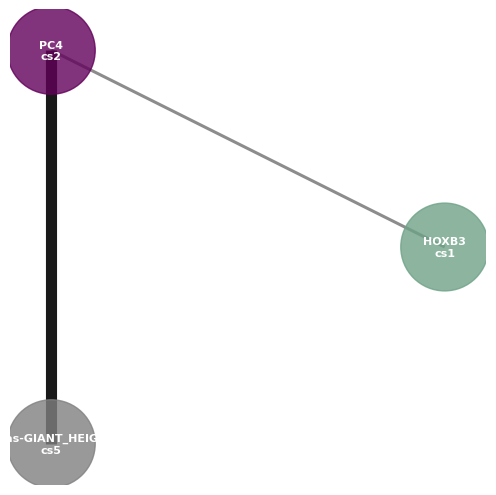

In [ ]:
# Create an undirected graph
G = nx.Graph()

# Add edges to the graph with weights
for index, row in pd.concat([cluster_pairs_qtl, cluster_gwas_pairs]).iterrows():
    G.add_edge(row['id1_short'], row['id2_short'], weight=row['PP.H4.abf'])

# Get edge weights for thickness
edge_weights = [G[u][v]['weight']*8 for u, v in G.edges()]
edge_colors = ['k' if G[u][v]['weight'] > 0.75 else 'gray' for u, v in G.edges()]
node_colors = [qtl_palette['Neither'] if 'gwas' in node else qtl_palette['pcQTL only'] if 'PC' in node else qtl_palette['eQTL only'] for node in G.nodes()]

fig, ax = plt.subplots(figsize=(5, 5)) 

# Use a rescaled circular layout to prevent nodes from running off the edge
pos = nx.circular_layout(G)
nx.draw_networkx_nodes(G, pos, node_size=4000, node_color=node_colors, alpha=.8, ax=ax)
nx.draw_networkx_edges(G, pos, width=edge_weights, edge_color=edge_colors, alpha=.9, ax=ax)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=8, font_color='white', font_weight='bold')
ax.axis('off')  # Turn off the axis

plt.tight_layout()
plt.savefig(f"{config['working_dir']}/workflow/supplemental_figures/figures/figure_s17_e.pdf", 
            transparent=True, bbox_inches='tight', dpi=300)

plt.show()

In [15]:
# afc information 
pcqtl_afc = load_across_tissues(config, load_pc_afc)
susie_annotated['gene_id'] = susie_annotated['cluster_id'].str.split('_')
susie_explode = susie_annotated.explode('gene_id')

# merge in afc information
susie_explode_afc = pd.merge(susie_explode, pcqtl_afc[['pid', 'sid', 'tissue_id', 'log2_aFC']], left_on=['gene_id', 'variant_id', 'tissue_id'], 
    right_on=['pid', 'sid', 'tissue_id'], how='left')

# pip-weighted afc over credible set
susie_explode_afc['pip_afc'] = susie_explode_afc['pip'] * susie_explode_afc['log2_aFC']
credible_set_grouped_afc = susie_explode_afc.groupby(['phenotype_id', 'cs_id', 'tissue_id', 'gene_id']).agg({'pip_afc':'sum', 'pip':'sum'}).reset_index()
credible_set_grouped_afc['pip_afc_weighted'] = credible_set_grouped_afc['pip_afc']/credible_set_grouped_afc['pip']
credible_set_grouped_afc['abs_pip_afc_weighted'] = credible_set_grouped_afc['pip_afc_weighted'].abs()
credible_set_grouped_afc[credible_set_grouped_afc['cs_id'] == example_cs_id]

,phenotype_id,cs_id,tissue_id,gene_id,pip_afc,pip,pip_afc_weighted,abs_pip_afc_weighted
1592,ENSG00000108511.9_ENSG00000120068.6_ENSG000001...,ENSG00000108511.9_ENSG00000120068.6_ENSG000001...,Esophagus_Muscularis,ENSG00000108511.9,0.160870,0.979156,0.164295,0.164295
1593,ENSG00000108511.9_ENSG00000120068.6_ENSG000001...,ENSG00000108511.9_ENSG00000120068.6_ENSG000001...,Esophagus_Muscularis,ENSG00000120068.6,-0.009607,0.979156,-0.009812,0.009812
1594,ENSG00000108511.9_ENSG00000120068.6_ENSG000001...,ENSG00000108511.9_ENSG00000120068.6_ENSG000001...,Esophagus_Muscularis,ENSG00000120075.5,0.288048,0.979156,0.294180,0.294180
1595,ENSG00000108511.9_ENSG00000120068.6_ENSG000001...,ENSG00000108511.9_ENSG00000120068.6_ENSG000001...,Esophagus_Muscularis,ENSG00000120093.11,0.579573,0.979156,0.591911,0.591911
1596,ENSG00000108511.9_ENSG00000120068.6_ENSG000001...,ENSG00000108511.9_ENSG00000120068.6_ENSG000001...,Esophagus_Muscularis,ENSG00000182742.5,0.106106,0.979156,0.108365,0.108365
1597,ENSG00000108511.9_ENSG00000120068.6_ENSG000001...,ENSG00000108511.9_ENSG00000120068.6_ENSG000001...,Esophagus_Muscularis,ENSG00000260027.4,0.185648,0.979156,0.189600,0.189600


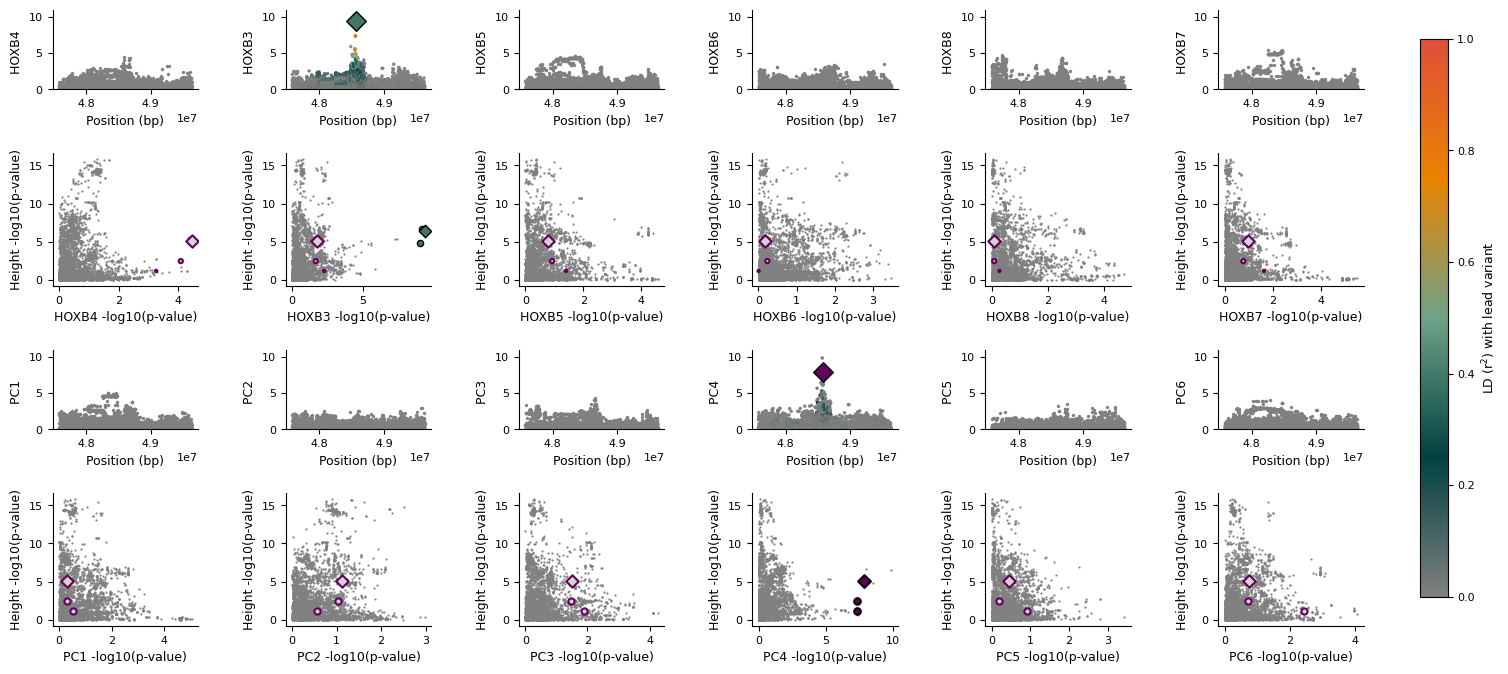

In [ ]:
# Combined plot with 4 rows: eGene position, eGene coloc, PC position, PC coloc

# Separate eQTL and pcQTL phenotypes
egene_phenotypes = list(nominal_e['phenotype_id'].unique())
pc_phenotypes = list(nominal_pc['phenotype_id'].unique())
example_cluster_cs = susie_annotated[susie_annotated['phenotype_id'].str.contains(example_cluster_id)]
phenotypes_with_cs = example_cluster_cs['phenotype_id'].unique()
n_egene = len(egene_phenotypes)
n_pc = len(pc_phenotypes)
n_gwas = len(example_gwas_traits)

# Set up the figure: 4 rows (eGene pos, eGene coloc, PC pos, PC coloc)
# Use different height ratios for the rows
ncols = max(n_egene, n_pc)
height_ratios = [1.5, 2.5, 1.5, 2.5]  # Example: position rows shorter, coloc rows taller
fig, ax = plt.subplots(
    nrows=4,
    ncols=ncols,
    figsize=(3 * ncols, sum(height_ratios) * 1),  # Adjust height to match ratios
    squeeze=False,
    gridspec_kw={'height_ratios': height_ratios, 'wspace': 0.6, 'hspace': 0.6}
)

# Row 0: eGene position plots
for i, pheno_id in enumerate(egene_phenotypes):
    cs_nominal = nominal_e[nominal_e['phenotype_id'] == pheno_id].copy()
    pheno_label = get_gene_name(pheno_id.split('_e_')[-1], config)
    cs_nominal['pos'] = cs_nominal['variant_id'].str.split('_').str[1].astype(int)

    if pheno_id in phenotypes_with_cs:
        cs_susie = susie_annotated[susie_annotated['phenotype_id'] == pheno_id]
        cs_variant_ids = cs_susie['variant_id'].unique()
        lead_variant_id = cs_susie[cs_susie['pip'] == cs_susie['pip'].max()]['variant_id'].values[0]
        cs_nominal['in_cs'] = cs_nominal['variant_id'].isin(cs_variant_ids)
        if lead_variant_id is not None and lead_variant_id in ld.index:
            ld_with_lead = ld.loc[lead_variant_id]
            cs_nominal = cs_nominal.set_index('variant_id')
            cs_nominal['ld_with_lead'] = ld_with_lead[cs_nominal.index].values ** 2
            cs_nominal = cs_nominal.reset_index()
        sns.scatterplot(
            data=cs_nominal, 
            x='pos', 
            y=-np.log10(cs_nominal['pval_nominal']), 
            hue='ld_with_lead', 
            palette=ld_palette, 
            edgecolor=None, 
            legend=False,
            s=5,
            alpha=1, 
            ax=ax[0, i], 
            hue_norm=ld_norm
        )
        if len(cs_susie) > 1:
            sns.scatterplot(
                data=cs_nominal[cs_nominal['in_cs']],
                x='pos',
                y=-np.log10(cs_nominal[cs_nominal['in_cs']]['pval_nominal']),
                hue='ld_with_lead', 
                palette=ld_palette, 
                marker='o',
                s=cs_susie['pip']*100,
                edgecolor='k',
                linewidth=1,
                alpha=1,
                ax=ax[0, i],
                legend=False, 
                hue_norm=ld_norm
            )
        sns.scatterplot(
            data=cs_nominal[cs_nominal['variant_id'] == lead_variant_id],
            x='pos',
            y=-np.log10(cs_nominal[cs_nominal['variant_id'] == lead_variant_id]['pval_nominal']),
            marker='D',
            color='#417865',
            s=100,
            edgecolor='k',
            linewidth=1,
            alpha=1,
            ax=ax[0, i],
            legend=False
        )
    else:
        sns.scatterplot(
            data=cs_nominal,
            x='pos',
            y=-np.log10(cs_nominal['pval_nominal']),
            color='grey',
            edgecolor=None,
            legend=False,
            s=5,
            alpha=1,
            ax=ax[0, i]
        )
    ax[0, i].set_ylabel(f"{pheno_label} ")
    ax[0, i].set_xlabel("Position (bp)")
    ax[0, i].spines['right'].set_visible(False)
    ax[0, i].spines['top'].set_visible(False)
    ax[0, i].set_ylim(0, -np.log10(rounded_min_pval)+1)

# Row 1: eGene coloc plots
for i, pheno_id in enumerate(egene_phenotypes):
    gene_id = pheno_id.split('_e_')[-1]
    for gwas_trait_idx in range(n_gwas):
        plot_egene_coloc(
            ax[1, i], 
            get_gene_name(gene_id, config), 
            gene_id, 
            nominal_e, 
            gwas_data[gwas_trait_idx], 
            gwas_names[gwas_trait_idx], 
            plot_egene_cs=(pheno_id in phenotypes_with_cs),
            plot_example_cs=True
        )


# Row 2: PC position plots
for i, pheno_id in enumerate(pc_phenotypes):
    cs_nominal = nominal_pc[nominal_pc['phenotype_id'] == pheno_id].copy()
    pc_num = int(pheno_id.split('_pc')[-1]) if '_pc' in pheno_id else 1
    pheno_label = f'PC{pc_num}'
    cs_nominal['pos'] = cs_nominal['variant_id'].str.split('_').str[1].astype(int)

    if pheno_id in phenotypes_with_cs:
        cs_susie = susie_annotated[susie_annotated['phenotype_id'] == pheno_id]
        cs_variant_ids = cs_susie['variant_id'].unique()
        lead_variant_id = cs_susie[cs_susie['pip'] == cs_susie['pip'].max()]['variant_id'].values[0]
        cs_nominal['in_cs'] = cs_nominal['variant_id'].isin(cs_variant_ids)
        if lead_variant_id is not None and lead_variant_id in ld.index:
            ld_with_lead = ld.loc[lead_variant_id]
            cs_nominal = cs_nominal.set_index('variant_id')
            cs_nominal['ld_with_lead'] = ld_with_lead[cs_nominal.index].values ** 2
            cs_nominal = cs_nominal.reset_index()
        sns.scatterplot(
            data=cs_nominal, 
            x='pos', 
            y=-np.log10(cs_nominal['pval_nominal']), 
            hue='ld_with_lead', 
            palette=ld_palette, 
            edgecolor=None, 
            legend=False,
            s=5,
            alpha=1, 
            ax=ax[2, i], 
            hue_norm=ld_norm
        )
        if len(cs_susie) > 1:
            sns.scatterplot(
                data=cs_nominal[cs_nominal['in_cs']],
                x='pos',
                y=-np.log10(cs_nominal[cs_nominal['in_cs']]['pval_nominal']),
                hue='ld_with_lead', 
                palette=ld_palette, 
                marker='o',
                s=cs_susie['pip']*100,
                edgecolor='k',
                linewidth=1,
                alpha=1,
                ax=ax[2, i],
                legend=False, 
                hue_norm=ld_norm
            )
        sns.scatterplot(
            data=cs_nominal[cs_nominal['variant_id'] == lead_variant_id],
            x='pos',
            y=-np.log10(cs_nominal[cs_nominal['variant_id'] == lead_variant_id]['pval_nominal']),
            marker='D',
            color='#62005A',
            s=100,
            edgecolor='k',
            linewidth=1,
            alpha=1,
            ax=ax[2, i],
            legend=False
        )
    else:
        sns.scatterplot(
            data=cs_nominal,
            x='pos',
            y=-np.log10(cs_nominal['pval_nominal']),
            color='grey',
            edgecolor=None,
            legend=False,
            s=5,
            alpha=1,
            ax=ax[2, i]
        )
    ax[2, i].set_ylabel(f"{pheno_label} ")
    ax[2, i].set_xlabel("Position (bp)")
    ax[2, i].spines['right'].set_visible(False)
    ax[2, i].spines['top'].set_visible(False)
    ax[2, i].set_ylim(0, -np.log10(rounded_min_pval)+1)

# Row 3: PC coloc plots
for i, pheno_id in enumerate(pc_phenotypes):
    pc_num = int(pheno_id.split('_pc')[-1]) if '_pc' in pheno_id else 1
    for gwas_trait_idx in range(n_gwas):
        plot_pcgene_coloc(
            ax[3, i], 
            pc_num, 
            nominal_pc, 
            gwas_data[gwas_trait_idx], 
            gwas_names[gwas_trait_idx], 
            plot_pc_cs=(pheno_id in phenotypes_with_cs),
            plot_example_cs=True
        )


# Add the LD colorbar to the right of the figure if any credible sets present
if any(pheno_id in phenotypes_with_cs for pheno_id in egene_phenotypes + pc_phenotypes):
    sm = mpl.cm.ScalarMappable(cmap=ld_palette, norm=ld_norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, orientation='vertical', fraction=0.02, pad=0.04)
    cbar.set_label('LD (r$^2$) with lead variant')

plt.savefig(f"{config['working_dir']}/workflow/supplemental_figures/figures/figure_s17.pdf", 
            transparent=True, bbox_inches='tight', dpi=300)
plt.show()